**Exploratory Data Analysis of AQI Dataset**

"We are analyzing air quality patterns across cities using weather, pollution, and temporal features to understand and predict AQI.”

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("aqi.csv")
df.head()

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,rolling_mean_6,rolling_mean_12,rolling_std_12,pm_ratio,gas_sum
0,lucknow,uttar pradesh,26.8467,80.9462,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,48.833332,107.000000,98.666664,155.666670,289.000000,109.972221,116.986110,36.597556,0.693130,600.3
1,bhubaneswar,odisha,20.2961,85.8245,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,169.833330,72.666664,117.500000,153.000000,90.000000,114.083333,116.083333,35.752270,0.655602,351.2
2,dehradun,uttarakhand,30.3165,78.0322,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,142.166670,48.833332,144.000000,100.333336,51.000000,108.361110,116.861110,35.478963,0.684066,729.2
3,panaji,goa,15.4909,73.8278,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,109.666664,169.833330,107.000000,158.666670,42.833332,119.638888,118.194444,37.439368,0.559633,126.3
4,ranchi,jharkhand,23.3441,85.3096,2022-08-05 00:00:00,8,Friday,False,monsoon,night,...,174.666670,142.166670,72.666664,96.000000,37.666668,133.777778,123.319444,38.323877,0.673239,347.5


In [4]:
df.shape

(842136, 44)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842136 entries, 0 to 842135
Data columns (total 44 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   city                 842136 non-null  object 
 1   state                842136 non-null  object 
 2   latitude             842136 non-null  float64
 3   longitude            842136 non-null  float64
 4   datetime             842136 non-null  object 
 5   month                842136 non-null  int64  
 6   day_name             842136 non-null  object 
 7   is_weekend           842136 non-null  bool   
 8   season               842136 non-null  object 
 9   time_of_day          842136 non-null  object 
 10  humidity_percent     842136 non-null  float64
 11  dew_point_c          842136 non-null  float64
 12  wind_gusts_kmh       842136 non-null  float64
 13  precipitation_mm     842136 non-null  float64
 14  is_raining           842136 non-null  bool   
 15  heavy_rain       

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,842136.0,23.129042,5.543476,8.524100,20.296100,23.831500,26.912400,31.104800
longitude,842136.0,82.769195,6.937195,72.571400,77.173400,80.946200,88.606500,94.108600
month,842136.0,6.801619,3.411546,1.000000,4.000000,7.000000,10.000000,12.000000
humidity_percent,842136.0,71.324145,21.362049,3.000000,58.000000,76.000000,89.000000,100.000000
dew_point_c,842136.0,17.160617,7.020444,-11.500000,12.100000,18.600000,23.300000,27.300000
wind_gusts_kmh,842136.0,19.270553,9.921463,3.200000,11.500000,17.300000,25.200000,55.100000
precipitation_mm,842136.0,0.197794,0.915800,0.000000,0.000000,0.000000,0.000000,51.700000
pressure_msl_hpa,842136.0,1009.489904,5.698810,979.400000,1005.400000,1009.900000,1013.800000,1028.100000
cloud_cover_percent,842136.0,50.500078,43.413394,0.000000,2.000000,47.000000,100.000000,100.000000
pm2_5_ugm3,842136.0,34.550208,29.652265,1.900000,14.700000,25.900000,44.200000,183.500000


In [7]:
df.isnull().sum()

city                   0
state                  0
latitude               0
longitude              0
datetime               0
month                  0
day_name               0
is_weekend             0
season                 0
time_of_day            0
humidity_percent       0
dew_point_c            0
wind_gusts_kmh         0
precipitation_mm       0
is_raining             0
heavy_rain             0
pressure_msl_hpa       0
cloud_cover_percent    0
pm2_5_ugm3             0
pm10_ugm3              0
co_ugm3                0
no2_ugm3               0
so2_ugm3               0
o3_ugm3                0
dust_ugm3              0
aod                    0
us_aqi                 0
aqi_category           0
pm25_category_india    0
festival_period        0
crop_burning_season    0
future_aqi_6h          0
timestamp              0
hour                   0
aqi_lag_1              0
aqi_lag_3              0
aqi_lag_6              0
aqi_lag_12             0
aqi_lag_24             0
rolling_mean_6         0


In [8]:
df.columns.tolist()

['city',
 'state',
 'latitude',
 'longitude',
 'datetime',
 'month',
 'day_name',
 'is_weekend',
 'season',
 'time_of_day',
 'humidity_percent',
 'dew_point_c',
 'wind_gusts_kmh',
 'precipitation_mm',
 'is_raining',
 'heavy_rain',
 'pressure_msl_hpa',
 'cloud_cover_percent',
 'pm2_5_ugm3',
 'pm10_ugm3',
 'co_ugm3',
 'no2_ugm3',
 'so2_ugm3',
 'o3_ugm3',
 'dust_ugm3',
 'aod',
 'us_aqi',
 'aqi_category',
 'pm25_category_india',
 'festival_period',
 'crop_burning_season',
 'future_aqi_6h',
 'timestamp',
 'hour',
 'aqi_lag_1',
 'aqi_lag_3',
 'aqi_lag_6',
 'aqi_lag_12',
 'aqi_lag_24',
 'rolling_mean_6',
 'rolling_mean_12',
 'rolling_std_12',
 'pm_ratio',
 'gas_sum']

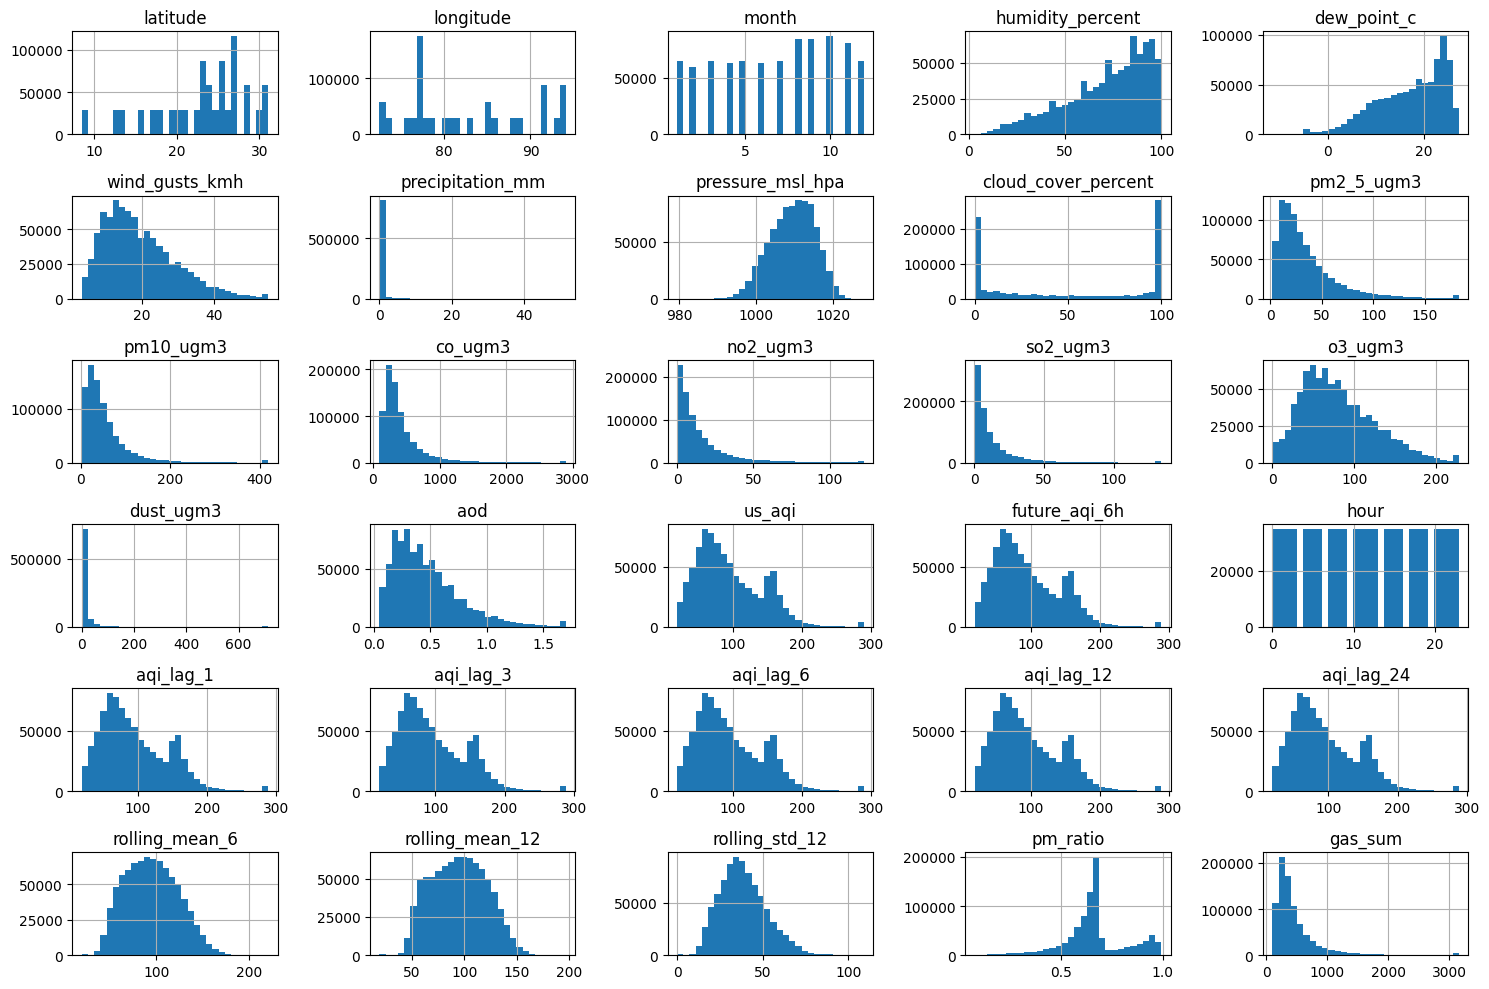

In [9]:
# Univariate Feature Analysis
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [10]:
# Categorical Features
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['city', 'state', 'datetime', 'day_name', 'season', 'time_of_day',
       'aqi_category', 'pm25_category_india', 'timestamp'],
      dtype='object')

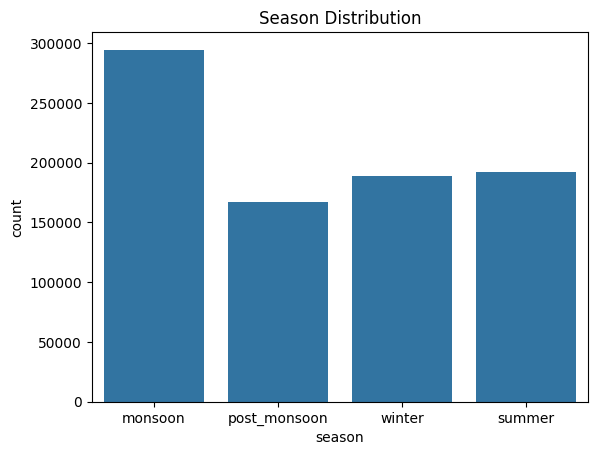

In [11]:
# Countplot
sns.countplot(x='season', data=df)
plt.title("Season Distribution")
plt.show()

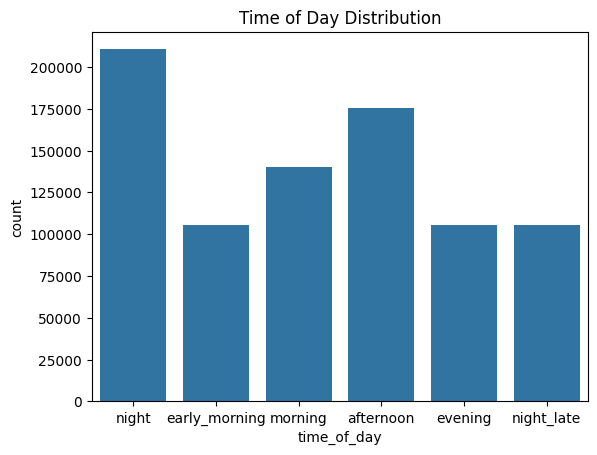

In [12]:
sns.countplot(x='time_of_day', data=df)
plt.title("Time of Day Distribution")
plt.show()

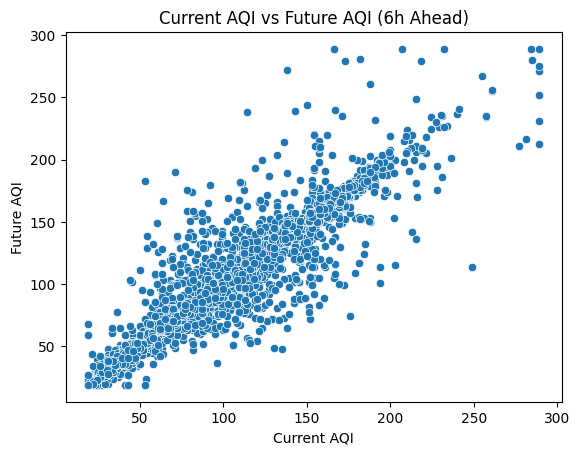

In [22]:
sns.scatterplot(x='us_aqi', y='future_aqi_6h', data=df.sample(5000))
plt.title("Current AQI vs Future AQI (6h Ahead)")
plt.xlabel("Current AQI")
plt.ylabel("Future AQI")
plt.show()

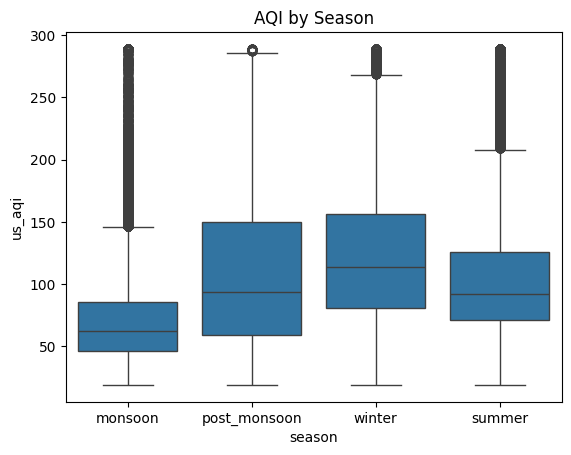

In [14]:
sns.boxplot(x='season', y='us_aqi', data=df)
plt.title("AQI by Season")
plt.show()

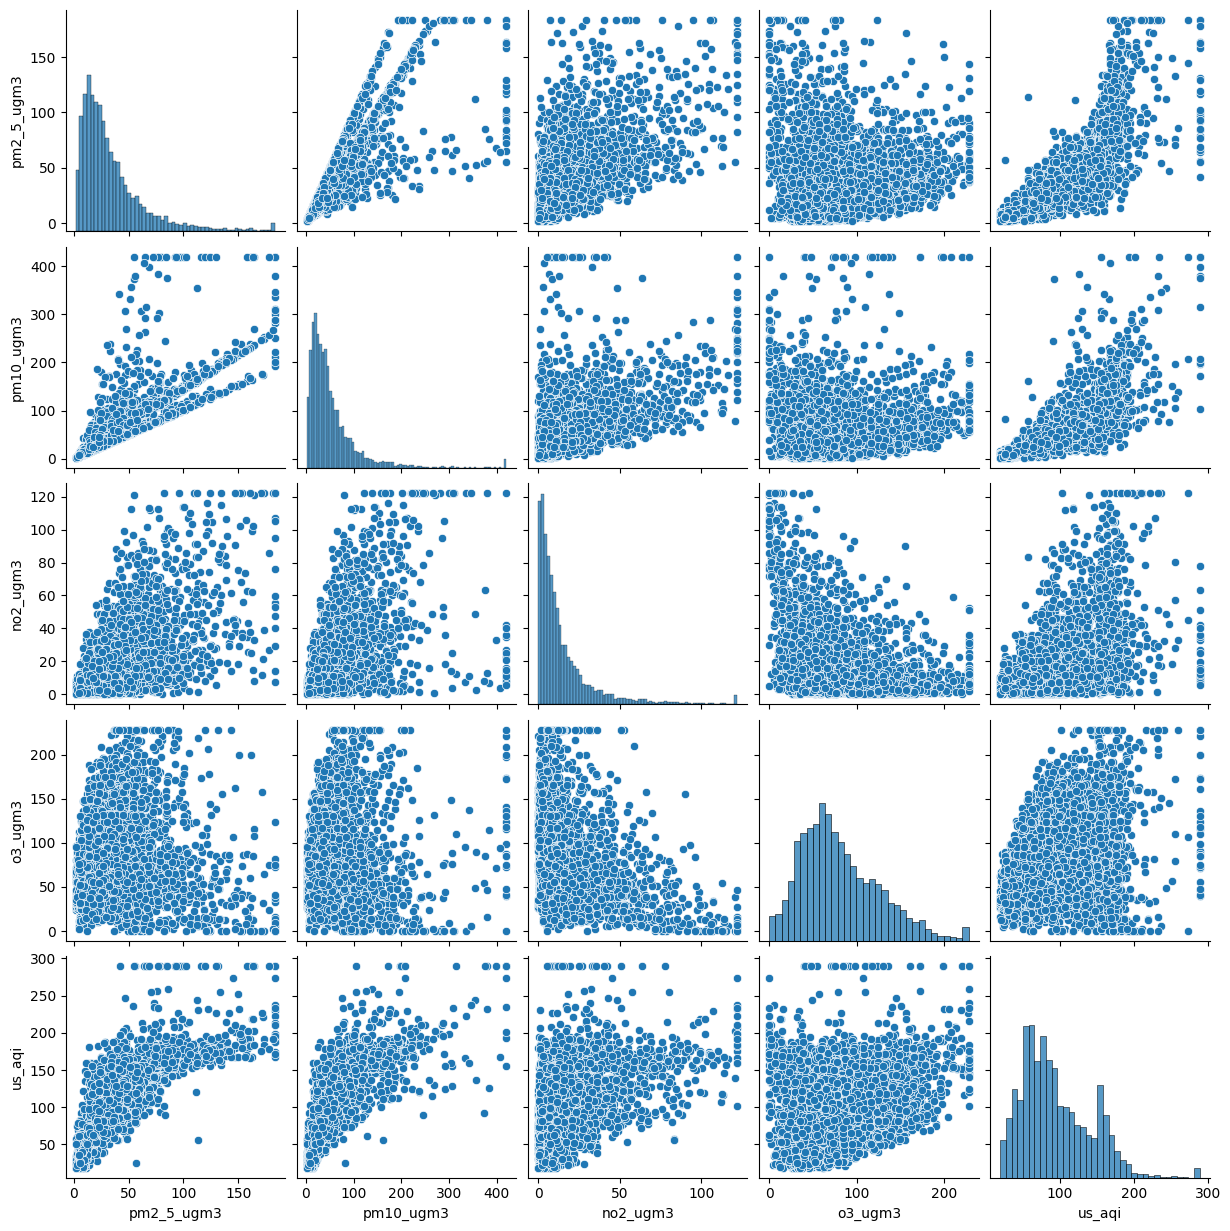

In [15]:
# Multivariate Feature Analysis
sample_df = df.sample(5000)

sns.pairplot(sample_df[['pm2_5_ugm3','pm10_ugm3','no2_ugm3','o3_ugm3','us_aqi']])
plt.show()

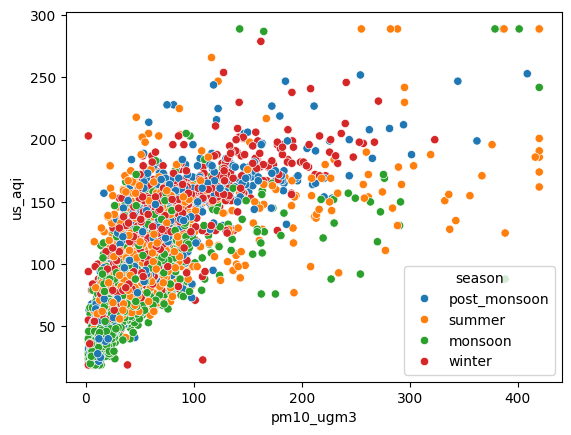

In [16]:
sns.scatterplot(x='pm10_ugm3', y='us_aqi', hue='season', data=df.sample(5000))
plt.show()

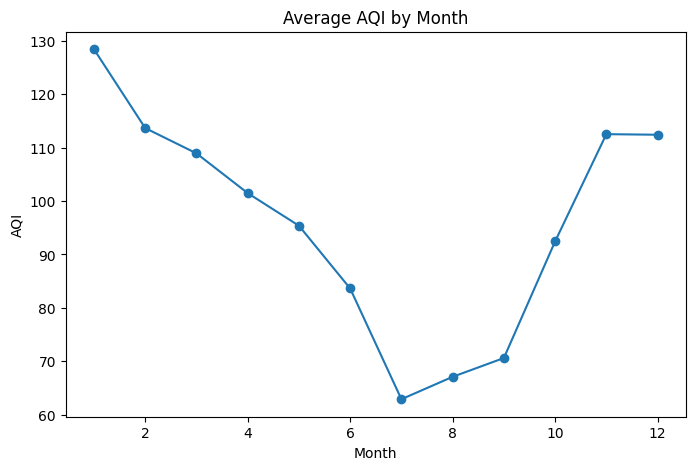

In [17]:
# Time Series Analysis - AQI trend by Month
monthly_aqi = df.groupby('month')['us_aqi'].mean()

monthly_aqi.plot(kind='line', marker='o', figsize=(8,5))
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

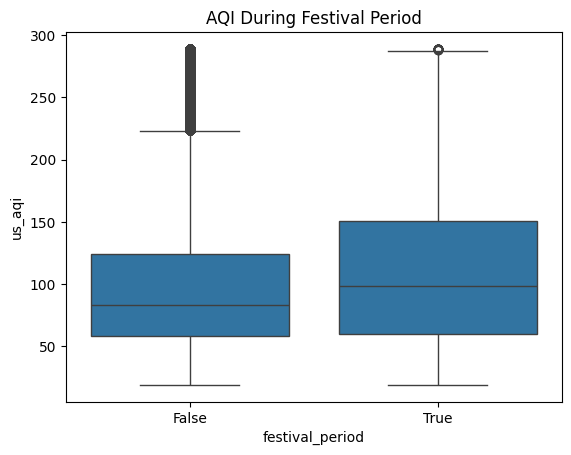

In [18]:
sns.boxplot(x='festival_period', y='us_aqi', data=df)
plt.title("AQI During Festival Period")
plt.show()

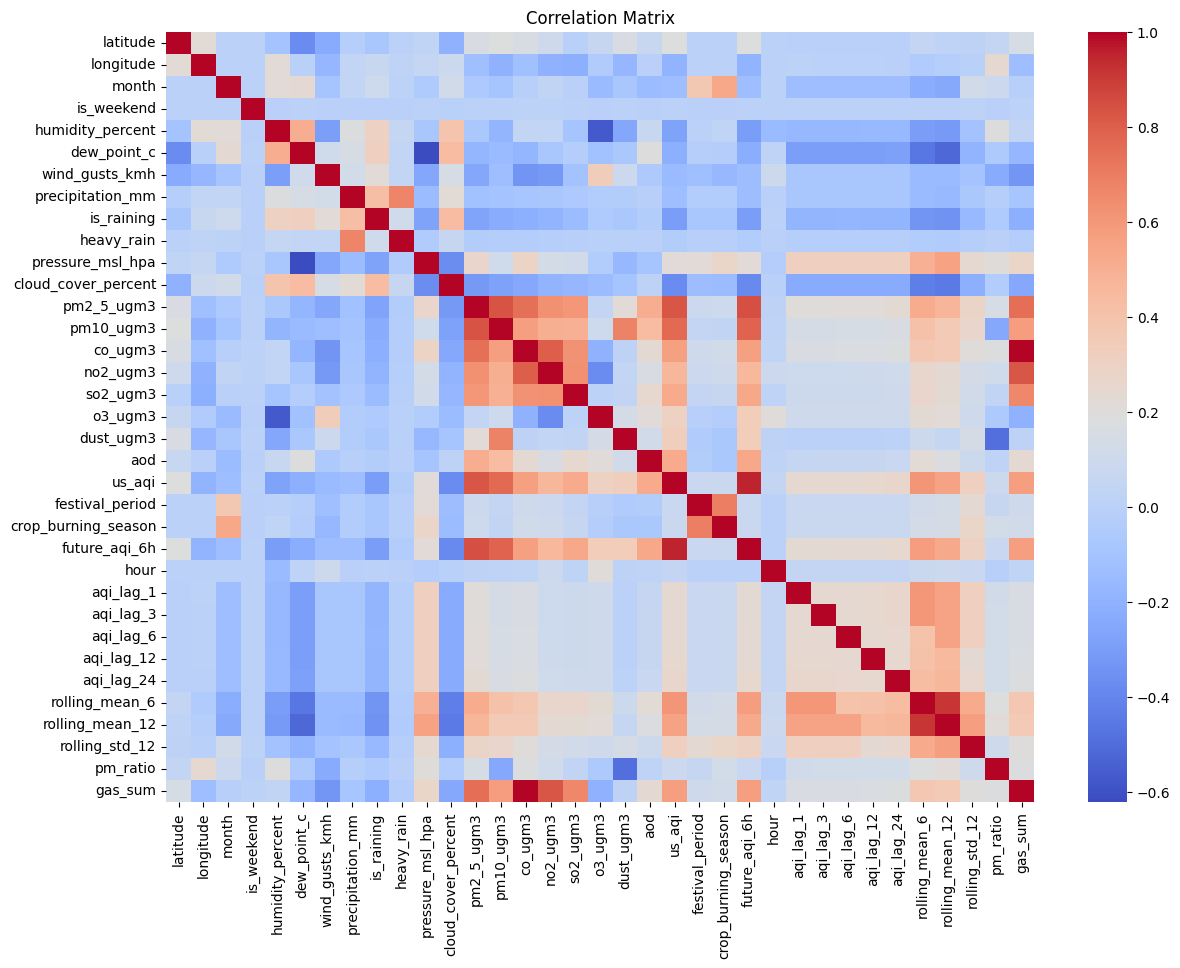

In [19]:
# Bivariate Feature Analysis - Correlation
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

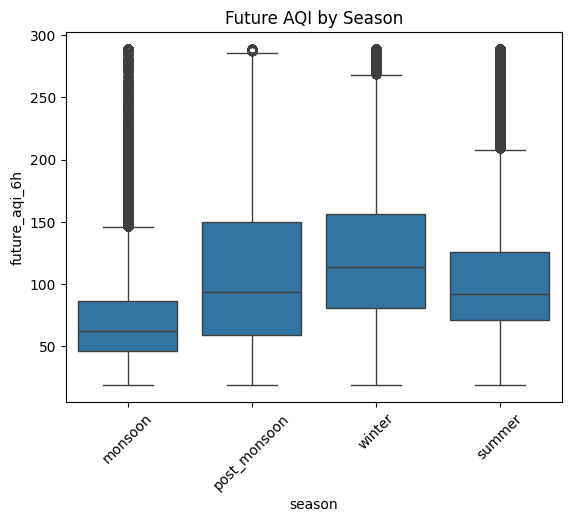

In [23]:
sns.boxplot(x='season', y='future_aqi_6h', data=df)
plt.title("Future AQI by Season")
plt.xticks(rotation=45)
plt.show()

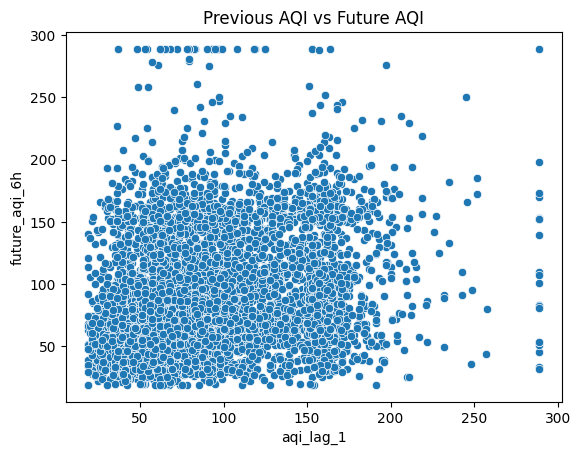

In [24]:
sns.scatterplot(x='aqi_lag_1', y='future_aqi_6h', data=df.sample(5000))
plt.title("Previous AQI vs Future AQI")
plt.show()